# MLP — training, tuning, and interpretability (real data)
Runs on Colab with a GPU runtime.

In [43]:


import os, shutil

repo_path = "/content/Flight-Delay-Forecasting"

if not os.path.exists(repo_path):
    !git clone https://{GITHUB_TOKEN}@github.com/kevinbrugnera/Flight-Delay-Forecasting.git {repo_path}
    %cd {repo_path}
    !git checkout develop
    !git config --global user.email "sarapasquato03@gmail.com"
    !git config --global user.name "sarapasquato"
else:
    %cd {repo_path}
    !git pull origin develop

models_dir = os.path.join(repo_path, "models")
os.makedirs(models_dir, exist_ok=True)

for filename, src_path in FILES_TO_PUSH:
    shutil.copy(src_path, os.path.join(models_dir, filename))

!git add models/
!git commit -m "{COMMIT_MESSAGE}"
!git push origin develop

print("✅ Pesi caricati su GitHub in models/")

Cloning into '/content/Flight-Delay-Forecasting'...
remote: Enumerating objects: 177, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 177 (delta 76), reused 128 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (177/177), 7.08 MiB | 23.30 MiB/s, done.
Resolving deltas: 100% (76/76), done.
/content/Flight-Delay-Forecasting
Branch 'develop' set up to track remote branch 'develop' from 'origin'.
Switched to a new branch 'develop'
[develop c85ebf5] new weights
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite models/mlp_weights.pt (76%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 1.61 MiB | 2.75 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/kevinbrugnera/Flight-Delay

In [45]:
import os
import shutil

repo_path = "/content/Flight-Delay-Forecasting"

# clone ONLY if not already present in this session
if not os.path.exists(repo_path):
    !git clone https://{GITHUB_TOKEN}@github.com/kevinbrugnera/Flight-Delay-Forecasting.git {repo_path}
    %cd {repo_path}
    !git checkout develop
    !git config --global user.email "sarapasquato03@gmail.com"
    !git config --global user.name "sarapasquato"
else:
    %cd {repo_path}
    !git pull origin develop  # pull any teammate changes before overwriting

# copy the updated notebook from Drive into the repo
filename = os.path.basename(NOTEBOOK_DRIVE_PATH)
shutil.copy(NOTEBOOK_DRIVE_PATH, os.path.join(repo_path, filename))

# commit and push
!git add {filename}
!git commit -m "{COMMIT_MESSAGE}"
!git push origin develop

print(f"\n✅ Done: {filename} uploaded to GitHub (develop branch)")

/content/Flight-Delay-Forecasting
From https://github.com/kevinbrugnera/Flight-Delay-Forecasting
 * branch            develop    -> FETCH_HEAD
Already up to date.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab_Notebooks/tabular_pipeline_aeolus_mlp.ipynb'

## Setup and Google Drive mount
Installs and loads the parquet files exported by tabular_pipeline_aeolus_data.ipynb.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, recall_score, classification_report, precision_score
import torch
import torch.nn as nn
import shap
#import psutil

In [21]:
## Setup Colab: Drive + GPU

from google.colab import drive
drive.mount('/content/drive')

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available: True
GPU: Tesla T4


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Loading the real dataset and building tensors
Categorical indices and normalized continuous features built as PyTorch tensors; category values unseen in train are remapped instead of left as invalid embedding indices.

In [23]:

data_dir =  "/content/drive/MyDrive/"

train_dataset = torch.load(data_dir + "new_train_flight_chain_2022.pt",
                          weights_only=False)
val_dataset = torch.load(data_dir + "new_val_flight_chain_2022.pt",
                          weights_only=False)
test_dataset = torch.load(data_dir + "new_test_flight_chain_2022.pt",
                          weights_only=False)

datasets = {"train": train_dataset, "val": val_dataset, "test": test_dataset}


target_col = "ARR_DELAY_BIN"
cat_cols = ["OP_CARRIER", "OP_CARRIER_FL_NUM", "FL_YEAR", "FL_MONTH", "FL_DAY", "FL_WEEK", "ORIGIN_INDEX", "DEST_INDEX"]
exclude_cols = {"ARR_DELAY", "DEP_DELAY", "ARR_DELAY_BIN", "DEP_DELAY_BIN", "_FLIGHT_DATE", "dep_hour_bucket"}
#feature_cols = [c for c in train_mlp.columns if c not in exclude_cols]

#print(train_mlp.shape, val.shape, test.shape)
#print(f"Features used ({len(feature_cols)}): {feature_cols}")

In [24]:
def tabular_rec(dense_feat, sparse_feat, dense_additional):
        batch_size, seq_len, _ = dense_feat.shape
        device = dense_feat.device

        # Categorical features as per pretrained_mlp's cat_cols:
        # ['OP_CARRIER', 'OP_CARRIER_FL_NUM', 'FL_YEAR', 'FL_MONTH', 'FL_DAY', 'FL_WEEK', 'ORIGIN_INDEX', 'DEST_INDEX']
        categorical_features = [
            sparse_feat[:, :, 6].float(),   # OP_CARRIER
            sparse_feat[:, :, 7].float(),   # OP_CARRIER_FL_NUM
            dense_additional[:, :, 0],      # FL_YEAR
            sparse_feat[:, :, 0].float(),   # FL_MONTH
            dense_additional[:, :, 1],      # FL_DAY
            dense_additional[:, :, 2],      # FL_WEEK
            sparse_feat[:, :, 4].float(),    # ORIGIN_INDEX
            sparse_feat[:, :, 5].float(),    # DEST_INDEX
        ]
        # Continuous features, updated based on new dense_additional indexing
        continuous_features = [
            dense_additional[:, :, 3],      # CRS_DEP_TIME_MIN
            dense_additional[:, :, 4],      # CRS_ARR_TIME_MIN
            dense_additional[:, :, 4] - dense_additional[:, :, 3], # CRS_ELAPSED_TIME
            torch.ones((batch_size, seq_len), device=device), # FLIGHTS
            dense_feat[:, :, 0],            # O_TEMP
            dense_feat[:, :, 2],            # O_PRCP
            dense_feat[:, :, 4],            # O_WSPD
            dense_feat[:, :, 1],            # D_TEMP
            dense_feat[:, :, 3],            # D_PRCP
            dense_feat[:, :, 5],            # D_WSPD
            dense_additional[:, :, 5],      # O_LATITUDE
            dense_additional[:, :, 6],      # O_LONGITUDE
            dense_additional[:, :, 7],      # D_LATITUDE
            dense_additional[:, :, 8],      # D_LONGITUDE
            dense_additional[:, :, 9],      # dep_hour_sin
            dense_additional[:, :, 10],     # dep_hour_cos
            dense_additional[:, :, 11],     # arr_hour_sin
            dense_additional[:, :, 12],     # arr_hour_cos
            dense_additional[:, :, 13],     # dow_sin
            dense_additional[:, :, 14],     # dow_cos
            dense_additional[:, :, 15],     # month_sin
            dense_additional[:, :, 16],     # month_cos
            dense_additional[:, :, 17],     # great_circle_km
            dense_additional[:, :, 18],     # origin_congestion_2h
        ]
        return torch.stack(categorical_features + continuous_features, dim=-1)  # [batch_size, seq_len, 32]

In [25]:
def scale_tensors(targets, mean, std):
    return (targets - mean.to(targets.device)) / std.to(targets.device)

def unscale_tensors(scaled, mean, std):
    return scaled * std.to(scaled.device) + mean.to(scaled.device)

# 1. On delays

all_delays = train_dataset.tensors[4]      # [N, seq_len, 2]
all_valid_lens = train_dataset.tensors[3]  # [N]

seq_len = all_delays.shape[1]
mask = torch.arange(seq_len).unsqueeze(0) < all_valid_lens.unsqueeze(1)  # [N, seq_len]

valid_delays = all_delays[mask].float()  # [total_valid_steps, 2]

delay_mean = valid_delays.mean(dim=0)  # shape [2]
delay_std = valid_delays.std(dim=0)    # shape [2]

print(f"Delay mean (ARR, DEP): {delay_mean} \n")
print(f"Delay std (ARR, DEP): {delay_std} \n")

delay_threshold_scaled = scale_tensors(torch.tensor([15.0, 15.0]), mean=delay_mean, std=delay_std)
print(f"Delay threshold: {delay_threshold_scaled} \n")

# 2. On dense features (Base: 6 features)
all_dense = train_dataset.tensors[0]  # [N, seq_len, 6]
valid_dense = all_dense[mask].float()  # [total_valid_steps, 6]
dense_mean = valid_dense.mean(dim=0)  # [6]
dense_std = valid_dense.std(dim=0)    # [6]

print("Dense Mean:", dense_mean, "\n")
print("Dense Std:", dense_std, "\n")

# 3. On dense additional features (Additional: 18 features)
all_dense_additional = train_dataset.tensors[5]  # [N, seq_len, 18]
valid_dense_additional = all_dense_additional[mask].float()  # [total_valid_steps, 18]
dense_additional_mean = valid_dense_additional.mean(dim=0)  # [18]
dense_additional_std = valid_dense_additional.std(dim=0)    # [18]

print("Dense Additional Mean:\n", dense_additional_mean, "\n")
print("Dense Additional Std:\n", dense_additional_std, "\n")

Delay mean (ARR, DEP): tensor([ 6.8309, 12.3743]) 

Delay std (ARR, DEP): tensor([54.0866, 52.0139]) 

Delay threshold: tensor([0.1510, 0.0505]) 

Dense Mean: tensor([16.0230, 16.6847,  0.0963,  0.0990, 12.6072, 13.1677]) 

Dense Std: tensor([10.8050, 10.8666,  0.7466,  0.7694,  8.6760,  8.7261]) 

Dense Additional Mean:
 tensor([ 2.0220e+03,  1.4899e+01,  2.6799e+01,  8.0698e+02,  9.0234e+02,
         3.6736e+01, -9.5116e+01,  3.6736e+01, -9.5120e+01, -1.1154e-01,
        -3.4399e-01, -2.7821e-01, -2.1745e-01,  3.1054e-02, -8.8367e-04,
        -1.8131e-02, -2.4029e-02,  1.3186e+03,  2.0482e+00]) 

Dense Additional Std:
 tensor([0.0000e+00, 8.8782e+00, 1.4835e+01, 2.9654e+02, 3.1251e+02, 6.0675e+00,
        1.8674e+01, 6.0693e+00, 1.8677e+01, 7.3757e-01, 5.7028e-01, 6.2930e-01,
        6.9231e-01, 6.9799e-01, 7.1543e-01, 7.0614e-01, 7.0743e-01, 9.6163e+02,
        1.7806e+00]) 



In [26]:
## Srotola le catene in righe piatte per volo, applica tabular_rec SU DATI
## GREZZI (non normalizzati) — importante: tabular_rec calcola al volo
## CRS_ELAPSED_TIME = CRS_ARR_TIME_MIN - CRS_DEP_TIME_MIN; se normalizzassimo
## PRIMA, questa differenza verrebbe calcolata su valori scalati, dando un
## risultato senza senso. Normalizziamo quindi DOPO, sull'output finale.

def unroll_split(dataset, tabular_rec_fn, cont_mean=None, cont_std=None):
    dense_feat, sparse_feat, labels, valid_lens, delays, dense_additional = dataset.tensors
    seq_len = dense_feat.shape[1]
    mask = torch.arange(seq_len).unsqueeze(0) < valid_lens.unsqueeze(1)

    combined = tabular_rec_fn(dense_feat, sparse_feat, dense_additional)  # [N, seq_len, 32]
    combined_valid = combined[mask]   # scarta il padding, resta solo un volo per riga
    labels_valid = labels[mask]

    X_cat = combined_valid[:, :8].long()
    X_cont_raw = combined_valid[:, 8:]
    y_arr, y_dep = labels_valid[:, 0].float(), labels_valid[:, 1].float()

    if cont_mean is None:  # fit SOLO se non passati (cioè solo sul train)
        cont_mean = X_cont_raw.mean(dim=0)
        cont_std = X_cont_raw.std(dim=0).clamp_min(1e-6)
    X_cont = (X_cont_raw - cont_mean) / cont_std

    return X_cat, X_cont, y_arr, y_dep, cont_mean, cont_std


X_cat_train, X_cont_train, y_arr_train, y_dep_train, cont_mean, cont_std = unroll_split(train_dataset, tabular_rec)
print(f"Total flights (train): {X_cat_train.shape[0]}")
X_cat_val, X_cont_val, y_arr_val, y_dep_val, _, _ = unroll_split(val_dataset, tabular_rec, cont_mean, cont_std)
print(f"Total flights (val): {X_cat_val.shape[0]}")
X_cat_test, X_cont_test, y_arr_test, y_dep_test, _, _ = unroll_split(test_dataset, tabular_rec, cont_mean, cont_std)
print(f"Total flights (val): {X_cat_test.shape[0]}")

Total flights (train): 3688075
Total flights (val): 1390791
Total flights (val): 1332357


In [27]:

# Categorical Features Cardinalities
# i.e. maximum number of distinct values for each categorical (sparse) feature

cat_cols = ["OP_CARRIER", "OP_CARRIER_FL_NUM", "FL_YEAR", "FL_MONTH", "FL_DAY", "FL_WEEK", "ORIGIN_INDEX", "DEST_INDEX"]
cardinalities = {col: int(X_cat_train[:, i].max().item()) + 2 for i, col in enumerate(cat_cols)}
continuous_cols = list(range(X_cont_train.shape[1]))  # 24, serve solo il conteggio per il Model
print("cardinalities:", cardinalities)


cardinalities: {'OP_CARRIER': 18, 'OP_CARRIER_FL_NUM': 6826, 'FL_YEAR': 2024, 'FL_MONTH': 13, 'FL_DAY': 33, 'FL_WEEK': 54, 'ORIGIN_INDEX': 323, 'DEST_INDEX': 323}


## TabularMLP model definition
Per-categorical embedding layers, concatenated with continuous features, two dense layers (64, 64 units) with dropout (0.4, 0.3); the 64-dim penultimate layer is exposed as a reusable embedding for the future fusion with the LSTM.

In [28]:
# Model

class TabularMLP(nn.Module):
    def __init__(self, cardinalities, cat_cols, n_continuous, hidden_dim=64, embedding_dim=64):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinalities[c], max(min(50, (cardinalities[c]+1)//2), 2)) for c in cat_cols
        ])
        total_emb_dim = sum(e.embedding_dim for e in self.embeddings)
        self.mlp = nn.Sequential(
            nn.Linear(total_emb_dim + n_continuous, hidden_dim), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(hidden_dim, embedding_dim), nn.ReLU(),
        )
        self.arr_head = nn.Sequential(nn.Dropout(0.3), nn.Linear(embedding_dim, 1))  # ritardo arrivo
        self.dep_head = nn.Sequential(nn.Dropout(0.3), nn.Linear(embedding_dim, 1))  # ritardo partenza

    def forward(self, x_cat, x_cont, return_embedding=False):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [x_cont], dim=1)
        embedding = self.mlp(x)
        logit_arr = self.arr_head(embedding).squeeze(1)
        logit_dep = self.dep_head(embedding).squeeze(1)
        if return_embedding:
            return logit_arr, logit_dep, embedding
        return logit_arr, logit_dep


model_mlp = TabularMLP(cardinalities, cat_cols, n_continuous=len(continuous_cols)).to(device)

In [29]:
print("NaN in X_cont_train:", torch.isnan(X_cont_train).sum().item())
print("NaN in X_cont_val:", torch.isnan(X_cont_val).sum().item())
print("Inf in X_cont_train:", torch.isinf(X_cont_train).sum().item())
print("cont_std with value 0 (for div/0 -> inf):", (cont_std == 0).sum())

NaN in X_cont_train: 0
NaN in X_cont_val: 0
Inf in X_cont_train: 0
cont_std with value 0 (for div/0 -> inf): tensor(0)


In [30]:
## Class weighting per lo sbilanciamento, calcolato sui voli srotolati del train

n_pos_arr = y_arr_train.sum().item()
n_neg_arr = len(y_arr_train) - n_pos_arr
pos_weight_arr = torch.tensor(n_neg_arr / max(n_pos_arr, 1), dtype=torch.float32)

n_pos_dep = y_dep_train.sum().item()
n_neg_dep = len(y_dep_train) - n_pos_dep
pos_weight_dep = torch.tensor(n_neg_dep / max(n_pos_dep, 1), dtype=torch.float32)

print(f"pos_weight_arr = {pos_weight_arr.item():.2f} ({int(n_pos_arr)} positivi su {len(y_arr_train)})")
print(f"pos_weight_dep = {pos_weight_dep.item():.2f} ({int(n_pos_dep)} positivi su {len(y_dep_train)})")

pos_weight_arr = 3.95 (744635 positivi su 3688075)
pos_weight_dep = 3.91 (751232 positivi su 3688075)


## Training loop, with early stopping on validation AUC
Batched forward/backward passes (batch size 4096) to fit in GPU memory.

In [31]:
## Training loop (with early stopping), tracking loss/AUC for both targets

def predict_in_batches(model, X_cat, X_cont, head="arr", batch_size=8192):
    """Runs the forward pass in batches, selecting the output of the
    requested head ('arr' or 'dep') from the model's tuple output."""
    model.eval()
    probs = []
    n = X_cat.shape[0]
    with torch.no_grad():
        for i in range(0, n, batch_size):
            logit_arr, logit_dep = model(X_cat[i:i+batch_size], X_cont[i:i+batch_size])
            logit = logit_arr if head == "arr" else logit_dep
            probs.append(torch.sigmoid(logit).cpu().numpy())
    return np.concatenate(probs)

def compute_loss_in_batches(model, criterion, X_cat, X_cont, y, head="arr", batch_size=8192):
    model.eval()
    total_loss, n_total = 0.0, 0
    with torch.no_grad():
        for i in range(0, X_cat.shape[0], batch_size):
            logit_arr, logit_dep = model(X_cat[i:i+batch_size], X_cont[i:i+batch_size])
            logit = logit_arr if head == "arr" else logit_dep
            yb = y[i:i+batch_size]
            loss = criterion(logit, yb)
            total_loss += loss.item() * len(yb)
            n_total += len(yb)
    return total_loss / n_total


criterion_arr = nn.BCEWithLogitsLoss(pos_weight=pos_weight_arr.to(device))
criterion_dep = nn.BCEWithLogitsLoss(pos_weight=pos_weight_dep.to(device))
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-3)

X_cat_train, X_cont_train = X_cat_train.to(device), X_cont_train.to(device)
X_cat_val, X_cont_val = X_cat_val.to(device), X_cont_val.to(device)
X_cat_test, X_cont_test = X_cat_test.to(device), X_cont_test.to(device)
y_arr_train, y_dep_train = y_arr_train.to(device), y_dep_train.to(device)
y_arr_val, y_dep_val = y_arr_val.to(device), y_dep_val.to(device)

batch_size = 4096
n_train = X_cat_train.shape[0]
best_val_auc, patience, patience_counter, best_state = 0.0, 5, 0, None

train_loss_arr_history, val_loss_arr_history = [], []
train_loss_dep_history, val_loss_dep_history = [], []
train_auc_arr_history, val_auc_arr_history = [], []
train_auc_dep_history, val_auc_dep_history = [], []

for epoch in range(30):
    model_mlp.train()
    perm = torch.randperm(n_train)
    epoch_loss = 0.0
    for i in range(0, n_train, batch_size):
        idx = perm[i:i + batch_size]
        xb_cat, xb_cont = X_cat_train[idx], X_cont_train[idx]
        yb_arr, yb_dep = y_arr_train[idx], y_dep_train[idx]

        optimizer.zero_grad()
        logit_arr, logit_dep = model_mlp(xb_cat, xb_cont)
        loss = criterion_arr(logit_arr, yb_arr) + criterion_dep(logit_dep, yb_dep)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)

    model_mlp.eval()
    train_loss_arr = compute_loss_in_batches(model_mlp, criterion_arr, X_cat_train, X_cont_train, y_arr_train, head="arr")
    val_loss_arr = compute_loss_in_batches(model_mlp, criterion_arr, X_cat_val, X_cont_val, y_arr_val, head="arr")
    train_loss_dep = compute_loss_in_batches(model_mlp, criterion_dep, X_cat_train, X_cont_train, y_dep_train, head="dep")
    val_loss_dep = compute_loss_in_batches(model_mlp, criterion_dep, X_cat_val, X_cont_val, y_dep_val, head="dep")

    train_prob_arr = predict_in_batches(model_mlp, X_cat_train, X_cont_train, head="arr")
    val_prob_arr = predict_in_batches(model_mlp, X_cat_val, X_cont_val, head="arr")
    train_prob_dep = predict_in_batches(model_mlp, X_cat_train, X_cont_train, head="dep")
    val_prob_dep = predict_in_batches(model_mlp, X_cat_val, X_cont_val, head="dep")

    train_auc_arr = roc_auc_score(y_arr_train.cpu().numpy(), train_prob_arr)
    val_auc_arr = roc_auc_score(y_arr_val.cpu().numpy(), val_prob_arr)
    train_auc_dep = roc_auc_score(y_dep_train.cpu().numpy(), train_prob_dep)
    val_auc_dep = roc_auc_score(y_dep_val.cpu().numpy(), val_prob_dep)

    train_loss_arr_history.append(train_loss_arr); val_loss_arr_history.append(val_loss_arr)
    train_loss_dep_history.append(train_loss_dep); val_loss_dep_history.append(val_loss_dep)
    train_auc_arr_history.append(train_auc_arr); val_auc_arr_history.append(val_auc_arr)
    train_auc_dep_history.append(train_auc_dep); val_auc_dep_history.append(val_auc_dep)

    val_auc_mean = (val_auc_arr + val_auc_dep) / 2
    print(f"Epoch {epoch+1:2d} | val_auc_arr={val_auc_arr:.4f} | val_auc_dep={val_auc_dep:.4f}")

    if val_auc_mean > best_val_auc:
        best_val_auc, patience_counter = val_auc_mean, 0
        best_state = {k: v.clone() for k, v in model_mlp.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (best val_auc={best_val_auc:.4f})")
            break

model_mlp.load_state_dict(best_state)

Epoch  1 | val_auc_arr=0.6943 | val_auc_dep=0.7066
Epoch  2 | val_auc_arr=0.6989 | val_auc_dep=0.7113
Epoch  3 | val_auc_arr=0.6984 | val_auc_dep=0.7106
Epoch  4 | val_auc_arr=0.6999 | val_auc_dep=0.7113
Epoch  5 | val_auc_arr=0.7003 | val_auc_dep=0.7118
Epoch  6 | val_auc_arr=0.6997 | val_auc_dep=0.7111
Epoch  7 | val_auc_arr=0.7000 | val_auc_dep=0.7114
Epoch  8 | val_auc_arr=0.7002 | val_auc_dep=0.7124
Epoch  9 | val_auc_arr=0.7012 | val_auc_dep=0.7131
Epoch 10 | val_auc_arr=0.7006 | val_auc_dep=0.7122
Epoch 11 | val_auc_arr=0.7021 | val_auc_dep=0.7138
Epoch 12 | val_auc_arr=0.7031 | val_auc_dep=0.7138
Epoch 13 | val_auc_arr=0.7008 | val_auc_dep=0.7119
Epoch 14 | val_auc_arr=0.7016 | val_auc_dep=0.7133
Epoch 15 | val_auc_arr=0.6992 | val_auc_dep=0.7107
Epoch 16 | val_auc_arr=0.7009 | val_auc_dep=0.7123
Epoch 17 | val_auc_arr=0.7003 | val_auc_dep=0.7118
Early stopping at epoch 17 (best val_auc=0.7084)


<All keys matched successfully>

## Final evaluation (train/val/test)
Same threshold-search protocol as LightGBM, batched at inference time too — the full train/val/test tensors don't fit in GPU memory for a single forward pass.

In [32]:
## Final evaluation — all metrics on train/val/test, for both targets

def predict_in_batches(model, X_cat, X_cont, head="arr", batch_size=8192):
    """head='arr' o 'dep' seleziona quale delle due teste usare."""
    model.eval()
    probs = []
    n = X_cat.shape[0]
    with torch.no_grad():
        for i in range(0, n, batch_size):
            logit_arr, logit_dep = model(X_cat[i:i+batch_size], X_cont[i:i+batch_size])
            logit = logit_arr if head == "arr" else logit_dep
            probs.append(torch.sigmoid(logit).cpu().numpy())
    return np.concatenate(probs)


def find_best_threshold_mlp(model, X_cat_val, X_cont_val, y_val, head="arr", thresholds=None):
    y_prob_val = predict_in_batches(model, X_cat_val, X_cont_val, head=head)
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)
    f1_scores = [f1_score(y_val.cpu().numpy(), (y_prob_val > t).astype(int)) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1_scores))]
    print(f"[{head}] Best threshold (on val, max F1): {best_t:.2f}")
    return best_t


def compute_metrics(model, X_cat, X_cont, y, threshold, head="arr"):
    y_prob = predict_in_batches(model, X_cat, X_cont, head=head)
    y_np = y.cpu().numpy()
    y_pred = (y_prob > threshold).astype(int)
    return {
        "auc": roc_auc_score(y_np, y_prob), "accuracy": accuracy_score(y_np, y_pred),
        "f1": f1_score(y_np, y_pred), "precision": precision_score(y_np, y_pred),
        "recall": recall_score(y_np, y_pred),
    }


def evaluate_mlp_all_splits(model, X_cat_train, X_cont_train, y_train,
                              X_cat_val, X_cont_val, y_val,
                              X_cat_test, X_cont_test, y_test, head="arr"):
    threshold = find_best_threshold_mlp(model, X_cat_val, X_cont_val, y_val, head=head)
    results = {
        "train": compute_metrics(model, X_cat_train, X_cont_train, y_train, threshold, head=head),
        "val":   compute_metrics(model, X_cat_val, X_cont_val, y_val, threshold, head=head),
        "test":  compute_metrics(model, X_cat_test, X_cont_test, y_test, threshold, head=head),
    }
    report = pd.DataFrame(results).T
    report.insert(0, "threshold", threshold)
    print(f"[{head}] Threshold used everywhere: {threshold:.2f}\n")
    print(report.round(4).to_string())
    gap_auc = results["train"]["auc"] - results["test"]["auc"]
    print(f"[{head}] AUC gap train-test: {gap_auc:.4f} {'⚠️ possible overfitting' if gap_auc > 0.05 else '✅ ok'}\n")
    return results


# valutazione separata per i due task, sugli stessi tensori X_*_train/val/test già pronti
metrics_mlp_arr = evaluate_mlp_all_splits(
    model_mlp, X_cat_train, X_cont_train, y_arr_train,
    X_cat_val, X_cont_val, y_arr_val, X_cat_test, X_cont_test, y_arr_test, head="arr",
)
metrics_mlp_dep = evaluate_mlp_all_splits(
    model_mlp, X_cat_train, X_cont_train, y_dep_train,
    X_cat_val, X_cont_val, y_dep_val, X_cat_test, X_cont_test, y_dep_test, head="dep",
)

model_mlp.eval()
with torch.no_grad():
    _, _, emb_sample = model_mlp(X_cat_test[:5], X_cont_test[:5], return_embedding=True)
print("Extracted tabular embedding shape:", emb_sample.shape)

[arr] Best threshold (on val, max F1): 0.50
[arr] Threshold used everywhere: 0.50

       threshold     auc  accuracy      f1  precision  recall
train        0.5  0.7313    0.6869  0.4543     0.3505  0.6454
val          0.5  0.7031    0.6484  0.4421     0.3357  0.6474
test         0.5  0.6873    0.6617  0.4032     0.3055  0.5929
[arr] AUC gap train-test: 0.0440 ✅ ok

[dep] Best threshold (on val, max F1): 0.55
[dep] Threshold used everywhere: 0.55

       threshold     auc  accuracy      f1  precision  recall
train       0.55  0.7348    0.7351  0.4638     0.3946  0.5625
val         0.55  0.7138    0.7032  0.4547     0.3793  0.5677
test        0.55  0.6999    0.7174  0.4159     0.3503  0.5117
[dep] AUC gap train-test: 0.0349 ✅ ok

Extracted tabular embedding shape: torch.Size([5, 64])


## Learning curve
Training/validation loss and AUC per epoch.

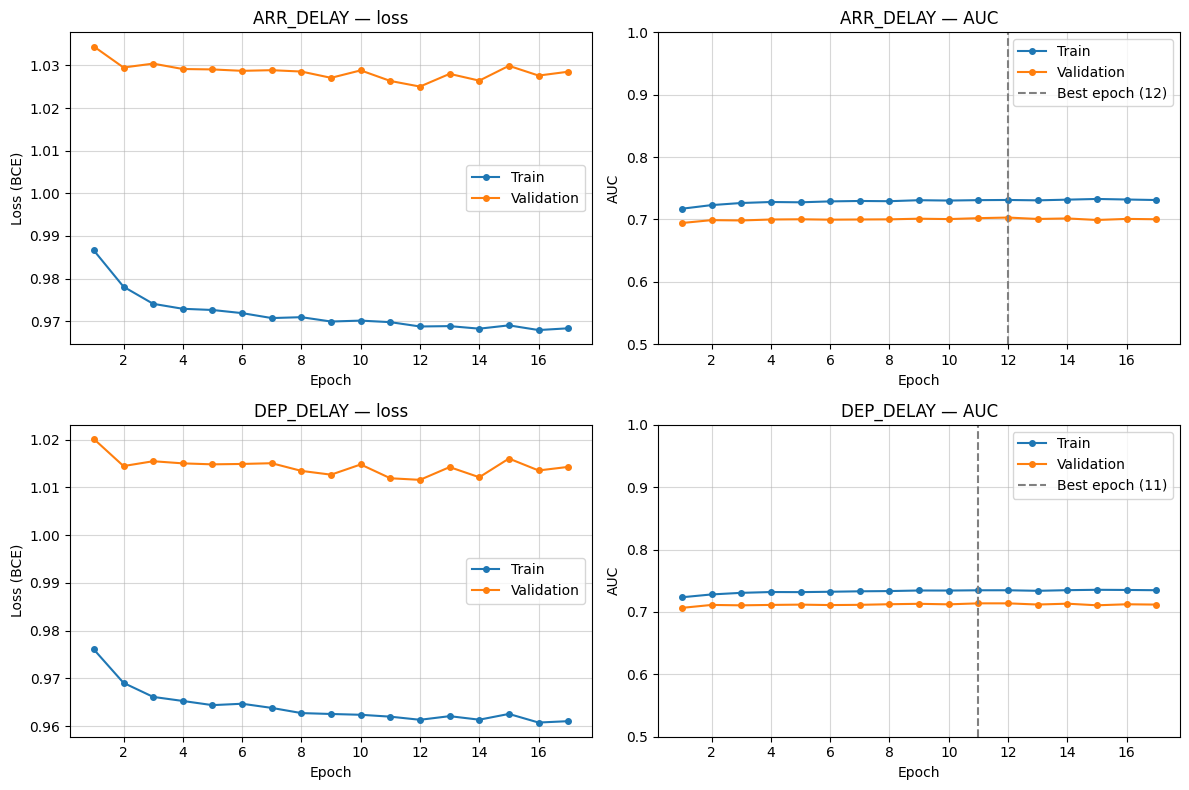

In [33]:
## Learning curve — MLP multi-task (loss e AUC for both targets)

epochs_range = list(range(1, len(train_auc_arr_history) + 1))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(epochs_range, train_loss_arr_history, marker="o", markersize=4, label="Train")
axes[0,0].plot(epochs_range, val_loss_arr_history, marker="o", markersize=4, label="Validation")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss (BCE)")
axes[0,0].set_title("ARR_DELAY — loss"); axes[0,0].legend(); axes[0,0].grid(alpha=0.5)

axes[0,1].plot(epochs_range, train_auc_arr_history, marker="o", markersize=4, label="Train")
axes[0,1].plot(epochs_range, val_auc_arr_history, marker="o", markersize=4, label="Validation")
best_epoch_arr = epochs_range[val_auc_arr_history.index(max(val_auc_arr_history))]
axes[0,1].axvline(best_epoch_arr, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_arr})")
axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("AUC"); axes[0,1].set_ylim(0.5, 1)
axes[0,1].set_title("ARR_DELAY — AUC"); axes[0,1].legend(); axes[0,1].grid(alpha=0.5)

axes[1,0].plot(epochs_range, train_loss_dep_history, marker="o", markersize=4, label="Train")
axes[1,0].plot(epochs_range, val_loss_dep_history, marker="o", markersize=4, label="Validation")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("Loss (BCE)")
axes[1,0].set_title("DEP_DELAY — loss"); axes[1,0].legend(); axes[1,0].grid(alpha=0.5)

axes[1,1].plot(epochs_range, train_auc_dep_history, marker="o", markersize=4, label="Train")
axes[1,1].plot(epochs_range, val_auc_dep_history, marker="o", markersize=4, label="Validation")
best_epoch_dep = epochs_range[val_auc_dep_history.index(max(val_auc_dep_history))]
axes[1,1].axvline(best_epoch_dep, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_dep})")
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("AUC"); axes[1,1].set_ylim(0.5, 1)
axes[1,1].set_title("DEP_DELAY — AUC"); axes[1,1].legend(); axes[1,1].grid(alpha=0.5)

plt.tight_layout()
plt.savefig(data_dir + "mlp_learning_curve_multitask.png", dpi=150)
plt.show()

## Subgroup evaluation
AUC broken down by month and by top-volume origin airport, to check for seasonal drift or geographic bias not visible in the aggregate metric.

In [39]:
## Subgroup evaluation — MLP, for both targets

def subgroup_report_mlp_tensor(y_prob, y_true, group_values, threshold, top_n=None, min_support=30):
    """Versione per tensori: group_values è un tensore 1D con il valore
    della categoria di raggruppamento per ogni volo (es. X_cat_test[:, i]
    per la colonna categorica i-esima), non una colonna di DataFrame."""
    y_true_np = y_true.cpu().numpy() if torch.is_tensor(y_true) else y_true
    group_np = group_values.cpu().numpy() if torch.is_tensor(group_values) else group_values
    y_pred = (y_prob > threshold).astype(int)

    df_tmp = pd.DataFrame({"group": group_np, "y_true": y_true_np, "y_prob": y_prob, "y_pred": y_pred})
    rows = []
    for group_val, sub in df_tmp.groupby("group"):
        if len(sub) < min_support or sub["y_true"].nunique() < 2:
            continue
        rows.append({"group": group_val, "n": len(sub),
                      "auc": roc_auc_score(sub["y_true"], sub["y_prob"]),
                      "f1": f1_score(sub["y_true"], sub["y_pred"])})
    result = pd.DataFrame(rows).sort_values("n", ascending=False)
    return result.head(top_n).reset_index(drop=True) if top_n else result.reset_index(drop=True)


y_prob_test_arr = predict_in_batches(model_mlp, X_cat_test, X_cont_test, head="arr")
y_prob_test_dep = predict_in_batches(model_mlp, X_cat_test, X_cont_test, head="dep")
threshold_arr = find_best_threshold_mlp(model_mlp, X_cat_val, X_cont_val, y_arr_val, head="arr")
threshold_dep = find_best_threshold_mlp(model_mlp, X_cat_val, X_cont_val, y_dep_val, head="dep")

print(">>> ARR — by month")
print(subgroup_report_mlp_tensor(y_prob_test_arr, y_arr_test, X_cat_test[:, 3], threshold_arr))
print("\n>>> ARR — top 10 airports")
print(subgroup_report_mlp_tensor(y_prob_test_arr, y_arr_test, X_cat_test[:, 6], threshold_arr, top_n=10))

print(">>> DEP — by month")
print(subgroup_report_mlp_tensor(y_prob_test_dep, y_dep_test, X_cat_test[:, 3], threshold_dep))
print("\n>>> DEP — top 10 airports")
print(subgroup_report_mlp_tensor(y_prob_test_dep, y_dep_test, X_cat_test[:, 6], threshold_dep, top_n=10))

[arr] Best threshold (on val, max F1): 0.50
[dep] Best threshold (on val, max F1): 0.55
>>> ARR — by month
    group       n       auc        f1
0       5  127761  0.675208  0.420667
1      10  126639  0.688498  0.391554
2       8  122334  0.666574  0.325400
3       3  120436  0.705680  0.428727
4       9  112658  0.671552  0.333142
5       7  110510  0.690399  0.385496
6       6  109717  0.691533  0.480019
7       4  105351  0.670243  0.419250
8       2  104751  0.694026  0.380112
9       1  100379  0.688017  0.392685
10     11   97815  0.700854  0.469856
11      0   94006  0.626053  0.251468

>>> ARR — top 10 airports
   group      n       auc        f1
0     20  64815  0.684890  0.378732
1     86  56038  0.675528  0.435084
2     85  53622  0.694496  0.455985
3    228  52099  0.663126  0.375553
4    176  38835  0.647339  0.319648
5     66  38818  0.669466  0.393324
6    174  35216  0.694440  0.472664
7    277  34991  0.631877  0.296787
8    239  33313  0.706586  0.424948
9    182  32

## SHAP interpretability (model-agnostic)
A gradient-based SHAP explainer doesn't work with categorical embeddings (it tries to interpolate between category indices, which is meaningless), so a permutation-based, black-box explainer is used instead, wrapped around the model's predict function.

In [40]:
## SHAP — MLP (model-agnostic), percorso "catene" — usa X_cat_test/X_cont_test direttamente

def make_predict_fn(head):
    def predict_fn_mlp(X):
        X = np.asarray(X)
        n_cat = len(cat_cols)
        x_cat = torch.tensor(np.round(X[:, :n_cat]).astype("int64"), dtype=torch.long).to(device)
        x_cont = torch.tensor(X[:, n_cat:], dtype=torch.float32).to(device)
        with torch.no_grad():
            logit_arr, logit_dep = model_mlp(x_cat, x_cont)
            logit = logit_arr if head == "arr" else logit_dep
            prob = torch.sigmoid(logit).cpu().numpy()
        return prob
    return predict_fn_mlp


# nomi delle 24 feature continue, nello stesso ordine esatto usato da tabular_rec
continuous_names = [
    "CRS_DEP_TIME_MIN", "CRS_ARR_TIME_MIN", "CRS_ELAPSED_TIME", "FLIGHTS",
    "O_TEMP", "O_PRCP", "O_WSPD", "D_TEMP", "D_PRCP", "D_WSPD",
    "O_LATITUDE", "O_LONGITUDE", "D_LATITUDE", "D_LONGITUDE",
    "dep_hour_sin", "dep_hour_cos", "arr_hour_sin", "arr_hour_cos",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
    "great_circle_km", "origin_congestion_2h",
]
feature_cols_shap = cat_cols + continuous_names

X_all_test = torch.cat([X_cat_test.float(), X_cont_test], dim=1).cpu().numpy()

background = X_all_test[np.random.choice(len(X_all_test), 100, replace=False)]
sample = X_all_test[np.random.choice(len(X_all_test), 500, replace=False)]

shap_results = {}
for head in ["arr", "dep"]:
    explainer = shap.Explainer(make_predict_fn(head), background, algorithm="permutation")
    shap_values = explainer(sample)
    mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_cols_shap).sort_values(ascending=False)
    shap_results[head] = mean_abs_shap
    print(f"\n[{head}] Top 10 features by mean |SHAP|:")
    print(mean_abs_shap.head(10))

PermutationExplainer explainer: 501it [00:14, 15.85it/s]



[arr] Top 10 features by mean |SHAP|:
dep_hour_sin        0.052659
OP_CARRIER          0.046005
FL_WEEK             0.039627
month_cos           0.027420
CRS_DEP_TIME_MIN    0.026562
ORIGIN_INDEX        0.026273
dow_sin             0.025687
FL_DAY              0.023493
great_circle_km     0.021442
DEST_INDEX          0.021301
dtype: float64


PermutationExplainer explainer: 501it [00:11,  4.83it/s]                         


[dep] Top 10 features by mean |SHAP|:
dep_hour_sin        0.056694
OP_CARRIER          0.051395
FL_WEEK             0.038382
month_cos           0.028624
CRS_DEP_TIME_MIN    0.028069
ORIGIN_INDEX        0.025853
dow_sin             0.025373
FL_DAY              0.022046
great_circle_km     0.020748
DEST_INDEX          0.019459
dtype: float64


## Permutation feature importance
Measures the AUC drop from shuffling each feature independently.

In [37]:
## Feature importance — MLP (permutation importance)

import os

RESULTS_DIR = data_dir + "results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

def permutation_importance_mlp(model, X_cat, X_cont, y_true, feature_cols_cat, feature_cols_cont, head="arr", n_repeats=3, seed=42):
    rng = np.random.default_rng(seed)
    baseline_prob = predict_in_batches(model, X_cat, X_cont, head=head)
    baseline_auc = roc_auc_score(y_true.cpu().numpy(), baseline_prob)
    print(f"[{head}] Baseline AUC (no permutation): {baseline_auc:.4f}")

    importances = {}
    for i, col in enumerate(feature_cols_cat):
        drops = []
        for _ in range(n_repeats):
            X_cat_perm = X_cat.clone()
            perm_idx = torch.tensor(rng.permutation(X_cat.shape[0]))
            X_cat_perm[:, i] = X_cat[perm_idx, i]
            prob_perm = predict_in_batches(model, X_cat_perm, X_cont, head=head)
            drops.append(baseline_auc - roc_auc_score(y_true.cpu().numpy(), prob_perm))
        importances[col] = np.mean(drops)

    for i, col in enumerate(feature_cols_cont):
        drops = []
        for _ in range(n_repeats):
            X_cont_perm = X_cont.clone()
            perm_idx = torch.tensor(rng.permutation(X_cont.shape[0]))
            X_cont_perm[:, i] = X_cont[perm_idx, i]
            prob_perm = predict_in_batches(model, X_cat, X_cont_perm, head=head)
            drops.append(baseline_auc - roc_auc_score(y_true.cpu().numpy(), prob_perm))
        importances[col] = np.mean(drops)

    return pd.Series(importances).sort_values(ascending=False)


importance_mlp_arr = permutation_importance_mlp(model_mlp, X_cat_test, X_cont_test, y_arr_test, cat_cols, continuous_cols, head="arr")
print("\nTop 15 features (ARR, permutation importance — AUC drop):")
print(importance_mlp_arr.head(15))
importance_mlp_arr.to_csv(RESULTS_DIR + "mlp_feature_importance_arr.csv")

importance_mlp_dep = permutation_importance_mlp(model_mlp, X_cat_test, X_cont_test, y_dep_test, cat_cols, continuous_cols, head="dep")
print("\nTop 15 features (DEP, permutation importance — AUC drop):")
print(importance_mlp_dep.head(15))
importance_mlp_dep.to_csv(RESULTS_DIR + "mlp_feature_importance_dep.csv")

[arr] Baseline AUC (no permutation): 0.6873

Top 15 features (ARR, permutation importance — AUC drop):
OP_CARRIER      0.036752
14              0.035347
FL_WEEK         0.021986
21              0.012713
0               0.010114
ORIGIN_INDEX    0.008348
20              0.006582
4               0.006315
18              0.005525
DEST_INDEX      0.005242
5               0.004582
22              0.004548
11              0.003568
8               0.003526
17              0.003326
dtype: float64
[dep] Baseline AUC (no permutation): 0.6999

Top 15 features (DEP, permutation importance — AUC drop):
OP_CARRIER      0.045356
14              0.043775
FL_WEEK         0.020322
0               0.012494
21              0.012171
ORIGIN_INDEX    0.010095
18              0.006972
20              0.005746
22              0.004925
4               0.004219
2               0.003754
17              0.003604
5               0.003490
11              0.003028
1               0.002934
dtype: float64


In [41]:
## Saving MLP weights for fusion with LSTM

model_mlp.eval()   # disable Dropout: crucial before saving, otherwise
                    # anyone reloading the model risks non-deterministic predictions
                    # if they forget to call eval() after loading

model_weights_path = data_dir + "mlp_weights.pt"
torch.save(model_mlp.state_dict(), model_weights_path)
print(f"Weights saved successfully in: {model_weights_path}")

Weights saved successfully in: /content/drive/MyDrive/mlp_weights.pt
